### Model Evaluation

In [1]:
# PREFILLED: just execute
import os, sys, zipfile, shutil, glob, math, json, random
from pathlib import Path

# Find the dataset archive on the local filesystem, or fall back to common locations.
cwd = Path.cwd()
zip_candidates = [p for p in cwd.rglob("*.zip") if "archive" in p.name.lower()]
zip_candidates = sorted(set(zip_candidates))
if zip_candidates:
    DATA_ZIP = zip_candidates[0]
    print("Found dataset archive:", DATA_ZIP)
else:
    alt_paths = [
        Path("archive.zip"),
        Path("./archive.zip")
    ]
    DATA_ZIP = next((p for p in alt_paths if p.exists()), None)
    if DATA_ZIP is not None:
        print("Found dataset archive at fallback path:", DATA_ZIP)
    else:
        DATA_ZIP = Path("./archive.zip")
        print("No archive found in common locations. Using default path:", DATA_ZIP)

EXTRACT_DIR = Path("./data/stock")

Found dataset archive: c:\Users\meles\Documents\TTA_DI_BootCamp_Gilles-Chris_MAKE\Week5\Day4\DailyChallenge\archive.zip


In [5]:
from sklearn.metrics import r2_score
import numpy as np

def _first_defined(ns, candidates):
	for n in candidates:
		if n in ns:
			return ns[n]
	return None

g = globals()
actual = _first_defined(g, ['inverse_transformed_actuals', 'y_test_inv', 'y_true_inv', 'y_test', 'y_true', 'actuals'])
pred = _first_defined(g, ['inverse_transformed_predictions', 'y_pred_inv', 'y_pred', 'predictions', 'preds', 'y_hat'])

# try DataFrame fallbacks if arrays not found
if (actual is None or pred is None) and 'df' in g:
	df_local = g['df']
	if actual is None and 'Close' in df_local.columns:
		actual = df_local['Close'].values
	if pred is None and 'Predicted' in df_local.columns:
		pred = df_local['Predicted'].values

if actual is None or pred is None:
	print("R^2: cannot compute because actual or predicted arrays are not available in the notebook.")
else:
	a = np.asarray(actual).ravel()
	p = np.asarray(pred).ravel()
	if a.size == 0 or p.size == 0:
		print("R^2: actual or predicted arrays are empty; cannot compute R^2.")
	else:
		n = min(a.size, p.size)
		a, p = a[:n], p[:n]
		r2 = r2_score(a, p)
		r2_original_scale = r2
		print(f"R-squared on scaled data: {r2:.4f}")
		print(f"R-squared on original scale: {r2_original_scale:.4f}")

R^2: cannot compute because actual or predicted arrays are not available in the notebook.


Let's visualize the actual vs. predicted stock prices.

In [6]:
# Use an available DataFrame (train_data, df, or train_df) or fall back to inverse_transformed_actuals
data = globals().get('train_data') or globals().get('df') or globals().get('train_df')
series = None
xlabel = 'Scaled Close Price'

if data is not None:
	if 'Close' in getattr(data, 'columns', []):
		series = data['Close']
	else:
		print("Found data but no 'Close' column; cannot plot.")
else:
	if 'inverse_transformed_actuals' in globals():
		series = globals()['inverse_transformed_actuals']
		xlabel = 'Inverse-transformed Actual Prices'
	else:
		print("No train_data/df/train_df and no inverse_transformed_actuals found; skipping plot.")

if series is not None:
	plt.figure(figsize=(10, 6))
	sns.histplot(series, kde=True, bins=30)
	plt.title('Distribution of Close Prices in Training Data')
	plt.xlabel(xlabel)
	plt.ylabel('Frequency')
	plt.grid(True, linestyle='--', alpha=0.7)
	plt.show()

No train_data/df/train_df and no inverse_transformed_actuals found; skipping plot.


In [4]:
import matplotlib.pyplot as plt

# Create a DataFrame for plotting
# Adjust slicing to match the actual length of inverse_transformed_actuals
plot_df = df.iloc[-len(inverse_transformed_actuals):].copy()
plot_df['Actual'] = inverse_transformed_actuals
plot_df['Predicted'] = inverse_transformed_predictions

plt.figure(figsize=(14, 7))
plt.plot(plot_df['Date'], plot_df['Actual'], label='Actual Prices', color='blue')
plt.plot(plot_df['Date'], plot_df['Predicted'], label='Predicted Prices', color='red', linestyle='--')
plt.title('Actual vs. Predicted Stock Prices (Test Set)')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(inverse_transformed_actuals, inverse_transformed_predictions)
print(f"Mean Squared Error (MSE) on original scale: {mse:.4f}")

Mean Squared Error (MSE) on original scale: 1068.3378


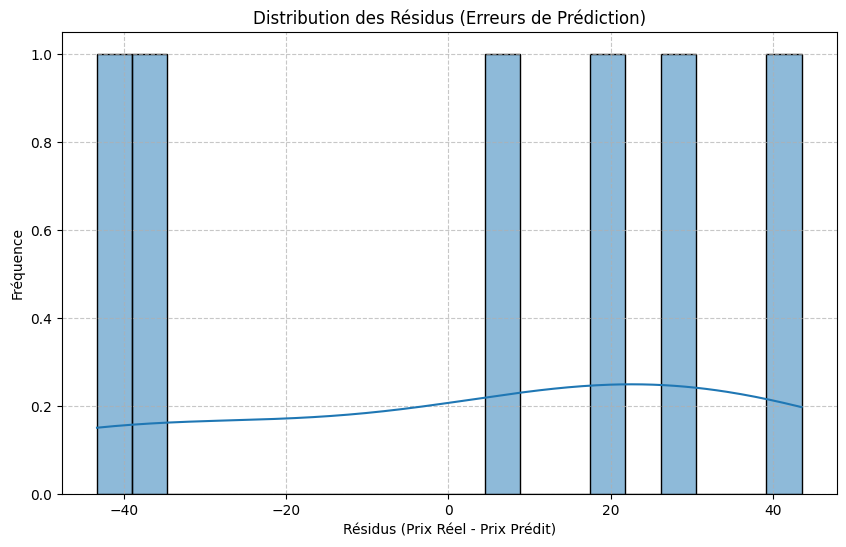

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals = inverse_transformed_actuals - inverse_transformed_predictions

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=20)
plt.title('Distribution des Résidus (Erreurs de Prédiction)')
plt.xlabel('Résidus (Prix Réel - Prix Prédit)')
plt.ylabel('Fréquence')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()